# Day 9 — Task Sheet_Linear Algebra II: Matrices and Transformations 

Part A — the curriculum activities

TASK 01
Visualise the four transformations

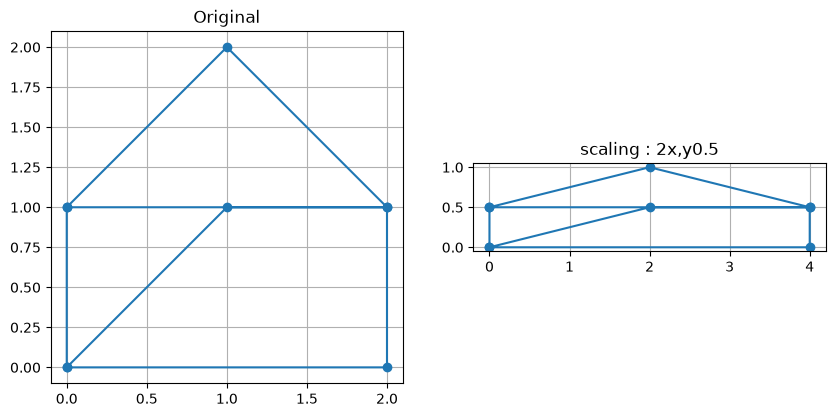

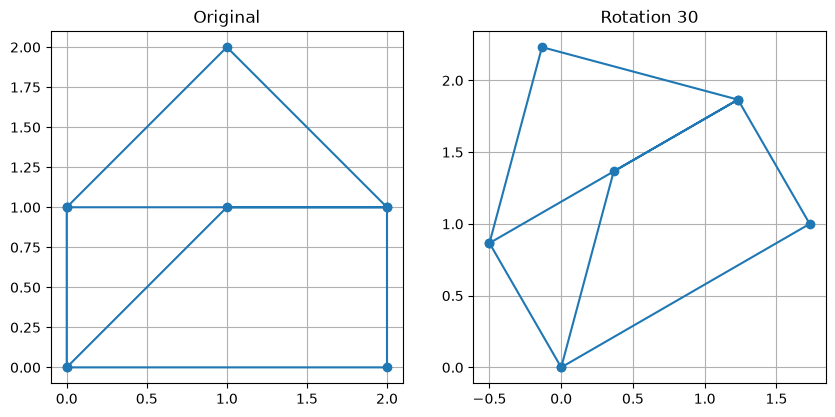

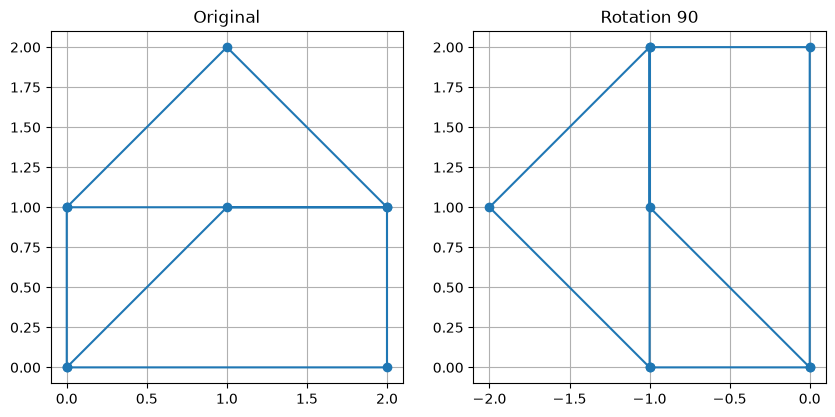

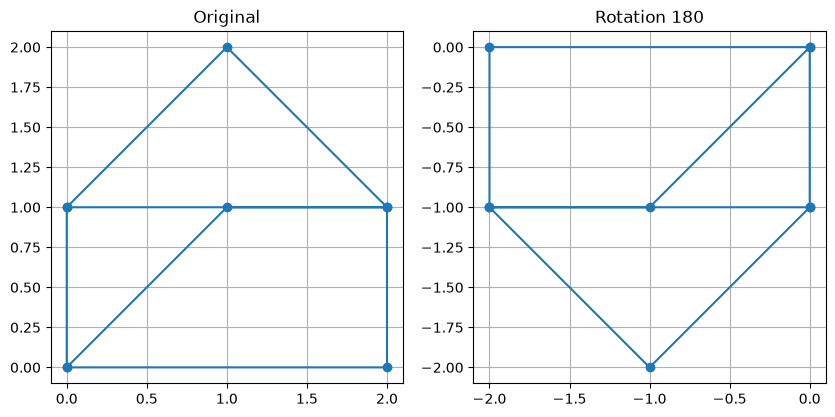

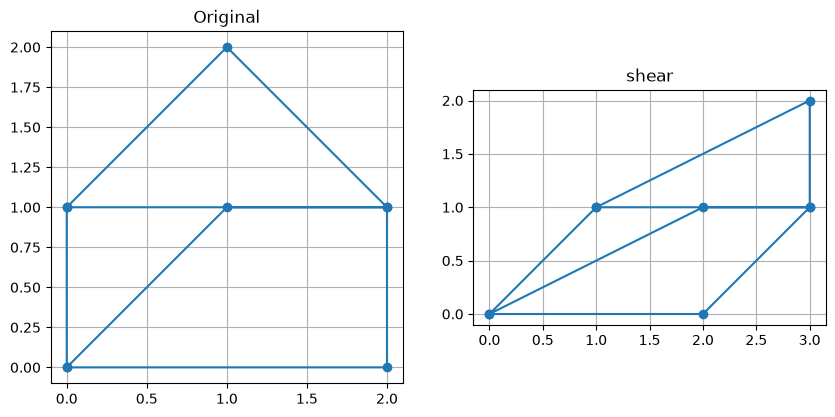

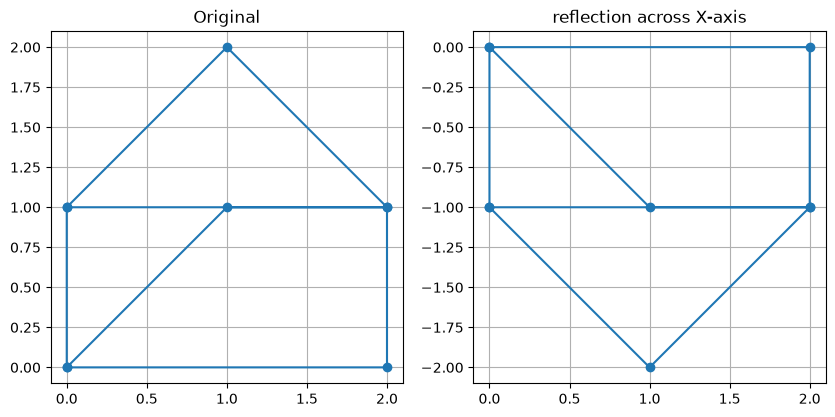

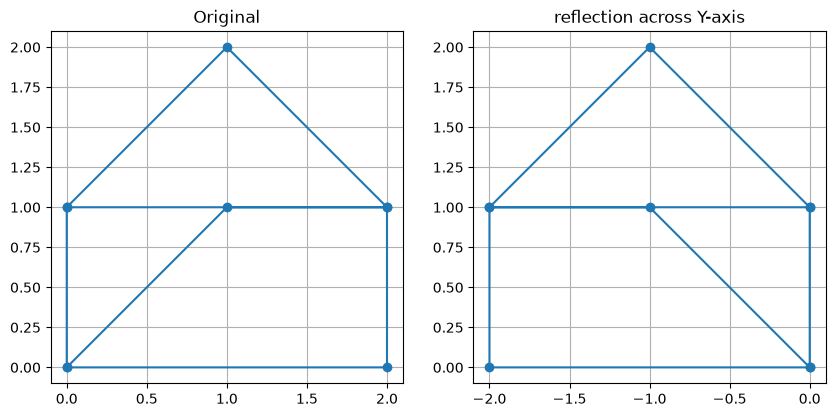

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Shape: a small house
shape = np.array([
    [0, 2, 2, 0, 0, 1, 2, 1, 0],
    [0, 0, 1, 1, 0, 1, 1, 2, 1]       
], dtype=float)

# Helper function
def show_transform(matrix, title= "Tranformation"):
    transformed = matrix @ shape
    
    fig,axes =plt.subplots(1,2, figsize=(10,5))
    
    # Original
    axes[0].plot(shape[0], shape[1], marker="o")
    axes[0].set_title("Original")
    axes[0].set_aspect("equal")
    axes[0].grid(True)
    
    # Transformed
    axes[1].plot(transformed[0], transformed[1], marker="o")
    axes[1].set_title(title)
    axes[1].set_aspect("equal")
    axes[1].grid(True)
    plt.show()
    
# Rotation
def rotation (degrees):
    theta = np.radians(degrees)
    
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])    
    
# scaling
scaling = np.array([
    [2,0],
    [0,0.5]
])

show_transform(scaling,"scaling : 2x,y0.5")

# rotation
show_transform(rotation(30), "Rotation 30")
show_transform(rotation(90), "Rotation 90")
show_transform(rotation(180), "Rotation 180")

# shear
shear = np.array([
    [1,1],
    [0,1]
])

show_transform(shear,"shear")

# Reflection across X-axis
reflection_x =np.array([
    [1,0],
    [0,-1]
])

show_transform(reflection_x,"reflection across X-axis")

# Reflection across y-axis
reflection_y =np.array([
    [-1,0],
    [0,1]
])

show_transform(reflection_y,"reflection across Y-axis")

Look It Up — Short Answers

1. Why is each point stored as a column? What breaks with rows?
Each column represents a point [x, y], so we can directly use matrix @ shape. With rows, the dimensions don't match, so we would need to transpose or change the multiplication.

2. Which entries change for clockwise rotation?
The signs of the two sin(θ) entries are reversed:

[[cosθ,  sinθ],
 [-sinθ, cosθ]]

3. What change to a scaling matrix creates a reflection?
Change one scaling value to a negative number.

Example:

[[1, 0],
 [0, -1]]

This reflects the shape across the x-axis.

Transformation observations
Scaling: x stretches, y squishes; origin stays fixed.
Rotation: shape turns around the origin; size stays unchanged.
Shear: shape becomes slanted; one direction remains unchanged.
Reflection: shape flips across an axis; size stays unchanged but orientation reverses.

TASK 02
Compute determinants and check invertibility

Sacling Determinant :  1.0
Rotation Determinant :  1.0
Shear Determinant :  1.0
Reflectaion X determinant :  -1.0
Reflectaion Y determinant :  -1.0

Singular MAtrix : 
[[1. 2.]
 [2. 4.]]
Singular determinant :  0.0


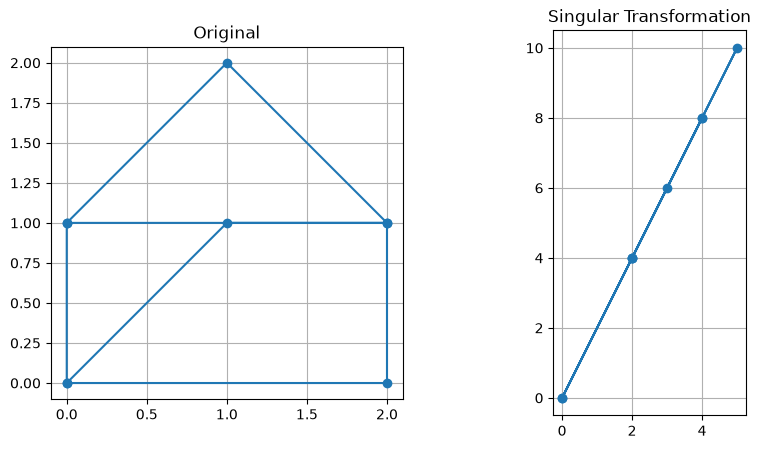

Inverse Error : 

Invertibility : 
Scaling : True
Rotation : True
shear : True
Reflection X : True
Reflection Y : True
Singular : False


In [15]:
# calculates determinanats of the transformation and check Invertibility

print("Sacling Determinant : ", np.linalg.det(scaling))
print("Rotation Determinant : ", np.linalg.det(rotation(30)))
print("Shear Determinant : ", np.linalg.det(shear))
print("Reflectaion X determinant : ", np.linalg.det(reflection_x))
print("Reflectaion Y determinant : ", np.linalg.det(reflection_y))

# create a singular matrix
# The second column is 2 times the first column
sing = np.array([
    [1.,2.],
    [2.,4.]
])

print("\nSingular MAtrix : ")
print(sing)

# Its determinant is zero, so information is lost
print("Singular determinant : ", np.linalg.det(sing))

# Apply the singular transformation to the shape
# The shape collapses into a line
show_transform(sing, "Singular Transformation" )

# Try to find the inverse
# A singular matrix cannot be inverted
try:
    inverse=np.linalg.inv(sing)
    print("Inverse : ")
    print(inverse)
except np.linalg.LinAlgError as e:
    print("Inverse Error : ")

# Function to check whether a matrix is invertible
def is_invertible(matrix):
    # If determinant is not zero, the matrix is invertible
    return not np.isclose(np.linalg.det(matrix),0)

 
# Store all matrices
matrices = {
    "Scaling" : scaling,
    "Rotation" : rotation(30),
    "shear" : shear,
    "Reflection X" : reflection_x,
    "Reflection Y" : reflection_y,
    "Singular" : sing
}
      
# Test every matrix
print("\nInvertibility : ")
for name, matrix in matrices.items():
    print(name,":",is_invertible(matrix))        


Look It Up — Short Answers

1. Why use np.isclose(det, 0) instead of det == 0?
Because floating-point calculations can produce tiny errors, such as 0.000000001 instead of exactly 0. np.isclose() treats sufficiently small values as zero. 

2. What does determinant 1 mean? What does negative mean?

det = 1: Area stays unchanged.
det < 0: Orientation is reversed, like a reflection.

3. What happens to the square with the singular matrix?
The square collapses into a line because one dimension is lost. You cannot recover the square because the transformation has lost information.

Done when: All determinants are calculated and matched with the visual results, and is_invertible() correctly returns True or False.

TASK 03
Verify associativity: (AB)C = A(BC)

(AB)C : 
[[1.73205081 1.48205081]
 [1.         1.4330127 ]]

A(BC) : 
[[1.73205081 1.48205081]
 [1.         1.4330127 ]]

Associative? True
Commutative? False


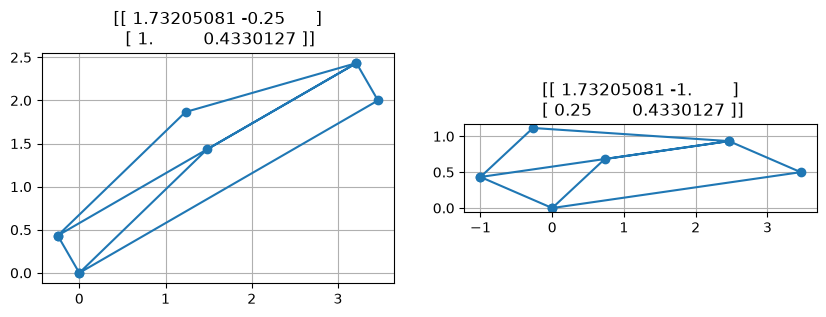

In [17]:
# Create three different 2×2 matrices:
# A = rotation, B = scaling, C = shear

A = rotation(30)

B = np.array([
    [2,0],
    [0,0.5]
])

C = np.array([
    [1,1],
    [0,1]
])

# Associativity: (A @ B) @ C = A @ (B @ C)
left = (A @ B) @ C
right = A @ (B @ C)

print("(AB)C : ")
print(left)

print("\nA(BC) : ")
print(right)

# allclose is used because floating-point calculations
# can have very small rounding differences.
print("\nAssociative?", np.allclose(left,right))

# Matrix multiplication is generally NOT commutative.
# Therefore, A @ B and B @ A can give different results.
print("Commutative?", np.allclose(A @ B, B @ A))

# Apply A @ B and B @ A to our shape
AB_shape = (A @ B) @ shape
BA_shape = (B @ A) @ shape

# Plot both results
fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].plot(AB_shape[0], AB_shape[1], marker="o")
axes[0].set_title(A @ B)
axes[0].set_aspect("equal")
axes[0].grid(True)

axes[1].plot(BA_shape[0], BA_shape[1], marker="o")
axes[1].set_title(B @ A)
axes[1].set_aspect("equal")
axes[1].grid(True)

plt.show()

Short explanation
Associative: Grouping does not matter: (AB)C = A(BC).
np.allclose() instead of ==: Handles tiny floating-point rounding differences.
Not commutative: A @ B and B @ A generally produce different results because the order of transformations matters.
The two plots should look different because the transformations are applied in a different order.

Look It Up — Short Answers

1. Associativity vs. commutativity

Associativity = grouping: (AB)C = A(BC) — matrix multiplication is associative.
Commutativity = order: AB = BA — matrix multiplication is generally not commutative.

2. Why does order matter geometrically?
Each matrix represents a transformation. Changing the order changes which transformation happens first, so the final shape can be different.
Example: Rotate then scale can give a different result from scale then rotate.

3. Which matrix acts first in A @ B @ C @ vector?
C acts first, then B, then A. Matrix transformations work from right to left.

Done when: np.allclose() confirms associativity, while A @ B and B @ A are different numerically and visually.

Part B — compose and apply

TASK 04
Compose a sequence of transformations

Combined Matrix : 
[[ 1.59099026 -0.53033009]
 [ 1.06066017  1.06066017]]

Same result?  True


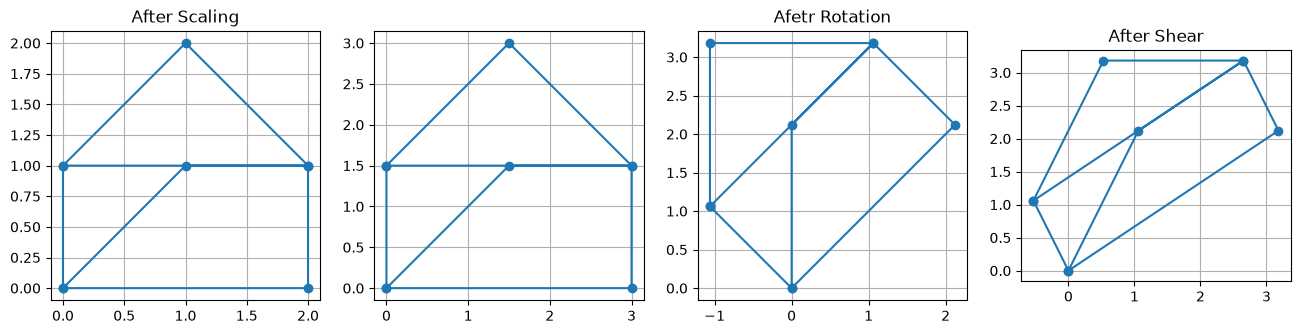


Determinant : 
det(S)        : 2.25
det(R)        : 1.0
det(Sh)       : 1.0
det(combined) : 2.2500000000000004
PRoduct of detminanats =  2.25
Determinants equal? =  True


In [26]:
# 1. Create the three transformation matrices

# Scale by 1.5
S = np.array([
    [1.5,0],
    [0,1.5]
])

# Rotate by 45 degrees 
R = rotation(45)

# Shaer horizontally
Sh = np.array([
    [1,0.5],
    [0,1]
])

# 2. Combine the transformations
# S is applied first, so it is on the RIGHT.
combined = Sh @ R @ S

print("Combined Matrix : ")
print(combined)

# 3. Apply transformations separately

stage1 = S @ shape # scale
stage2 = R @ stage1 # then rotate
stage3 = Sh @ stage2 # then shear

# 4. Apply the combined matrix in one step

combined_result = combined @ shape

# 5. Confirm both methods give the same result

print("\nSame result? ", np.allclose(stage3, combined_result))

# 6. Plot each stage

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].plot(shape[0], shape[1], marker="o")
axes[0].set_title("Original")

axes[1].plot(stage1[0], stage1[1], marker="o")
axes[0].set_title("After Scaling")

axes[2].plot(stage2[0], stage2[1], marker="o")
axes[2].set_title("Afetr Rotation")

axes[3].plot(stage3[0], stage3[1], marker="o")
axes[3].set_title("After Shear")


for ax in axes:
    ax.set_aspect("equal")
    ax.grid(True)

plt.show()

# 7. Compare determinants

det_S = np.linalg.det(S)
det_R = np.linalg.det(R)
det_Sh = np.linalg.det(Sh)
det_combined = np.linalg.det(combined)

print("\nDeterminant : ")

print("det(S)        :",det_S)
print("det(R)        :",det_R)
print("det(Sh)       :",det_Sh)
print("det(combined) :",det_combined)

print("PRoduct of detminanats = ", det_S * det_R * det_Sh)
print("Determinants equal? = ", np.isclose(det_combined, det_S * det_R * det_Sh))


Look It Up — Short Answers

1. Why is the first transformation on the RIGHT?
Matrix multiplication acts on vectors from right to left. So in Sh @ R @ S @ shape, S acts first, then R, then Sh.

2. Why do determinants multiply? What does it mean for area?
Each determinant represents an area-scaling factor. Applying two transformations multiplies their area changes, so det(AB) = det(A) × det(B).

3. What if one matrix is singular?
The whole composition becomes singular because information is lost. The shape collapses and cannot be fully recovered.

TASK 05
Special matrices and their properties

In [34]:
# ---------------------------------------------------------
# 1. DIAGONAL MATRIX
# ---------------------------------------------------------
# A diagonal matrix has values only on the main diagonal.
# It scales x and y independently without rotating.

D = np.array([
    [2., 0.],
    [0., 0.5]
])

v = np.array([2., 4.])

print("Diagonal Matrix : ")
print(D)

print("\nOriginal Vectors : ", v)
print("After diagonal transformations : ", D @ v)

# Since the off-diagonal values are 0, there is no rotation/shear.
print("Only Scales? ", np.allclose(D @ v, [4., 2.]))

# ---------------------------------------------------------
# 2. SYMMETRIC MATRIX
# ---------------------------------------------------------
# A matrix is symmetric when A == A.T

sym = np.array([
    [2., 1.],
    [1., 3.]
])

print("\nSymMetric Matrix : ")
print(sym)
print("Transpose : ")
print(sym.T)


# ---------------------------------------------------------
# 3. ORTHOGONAL MATRIX
# ---------------------------------------------------------
# A rotation matrix is orthogonal.
# For an orthogonal matrix Q:
# Q.T @ Q = Identity

Q = rotation(30)

print("\nOrthogonal matrix Q : ")
print(Q)

identity = np.eye(2)

print("\nQ.T @ Q :")
print(Q.T @ Q)

print("Orthogonal? ", np.allclose(Q.T @ Q, identity))

# ---------------------------------------------------------
# 4. ORTHOGONAL MATRIX PRESERVES LENGTH
# ---------------------------------------------------------
# Choose a vector and compare its length before and after rotation.

v = np.array([3., 4.])

original_length = np.linalg.norm(v)
new_length = np.linalg.norm(Q @ v)

print("\nOriginal vector : ", v)
print("Original Length : ", original_length)
print("Transformed vector : ", Q @ v)
print("New Length : ", new_length)

print("Length kept? ", np.isclose(new_length, original_length))

# ---------------------------------------------------------
# 5. ORTHOGONAL MATRIX PRESERVES ANGLES
# ---------------------------------------------------------
# Choose two vectors.
# Calculate their angle using the dot product.


v1 = np.array([1., 0.])
v2 = np.array([1., 1.])

def angle_between(a,b):
    cosine = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    return np.degrees(np.arccos(np.clip(cosine, -1, 1))) 

original_angle = angle_between(v1, v2)

# Rotate both vectors

v1_rotated = Q @ v1
v2_rotated = Q @ v2


new_angle =angle_between(v1_rotated, v2_rotated)

print("Original Angle: ", original_angle, "degrees")
print("New Angle : ", new_angle, "degrees")

print("Angle kept? ", np.isclose(new_angle, original_angle))

# ---------------------------------------------------------
# 6. WHY ORTHOGONAL MATRICES ARE USEFUL IN ML
# ---------------------------------------------------------

print("\nML use:")
print("Orthogonal matrices are useful in ML because they preserve")
print("lengths and angles, helping transformations avoid unwanted")
print("distortion of the data.")

Diagonal Matrix : 
[[2.  0. ]
 [0.  0.5]]

Original Vectors :  [2. 4.]
After diagonal transformations :  [4. 2.]
Only Scales?  True

SymMetric Matrix : 
[[2. 1.]
 [1. 3.]]
Transpose : 
[[2. 1.]
 [1. 3.]]

Orthogonal matrix Q : 
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]

Q.T @ Q :
[[1.00000000e+00 7.43708407e-18]
 [7.43708407e-18 1.00000000e+00]]
Orthogonal?  True

Original vector :  [3. 4.]
Original Length :  5.0
Transformed vector :  [0.59807621 4.96410162]
New Length :  5.0
Length kept?  True
Original Angle:  45.00000000000001 degrees
New Angle :  45.00000000000001 degrees
Angle kept?  True

ML use:
Orthogonal matrices are useful in ML because they preserve
lengths and angles, helping transformations avoid unwanted
distortion of the data.


### Look it up?

1. **What makes a matrix orthogonal?**
   A matrix \(Q\) is orthogonal when its transpose equals its inverse:

   $$
   Q^T = Q^{-1}
   $$

   Equivalently, \(Q^TQ=I\). ([ScienceDirect][1])

2. **Why are rotations/reflections orthogonal, but shears/scalings are not?**
   Rotations and reflections preserve **lengths and angles**, so they are orthogonal. Shears and non-unit scalings change lengths or angles, so they are not orthogonal. ([Math Research UTSA][2])

3. **Why are covariance matrices being symmetric useful?**
   Symmetry makes the relationships between variables consistent in both directions and gives useful mathematical properties, such as real eigenvalues and orthogonal eigenvectors, which helps in methods like PCA. ([Brooklyn College User Home][3])



Part C — put it together

TASK 06
An interactive transformation explorer

1. Pure rotation
Matrix : 
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Basis e1 lands at :  [0.70710678 0.70710678]
Basis e2 lands at :  [-0.70710678  0.70710678]
Determinant :  1.0


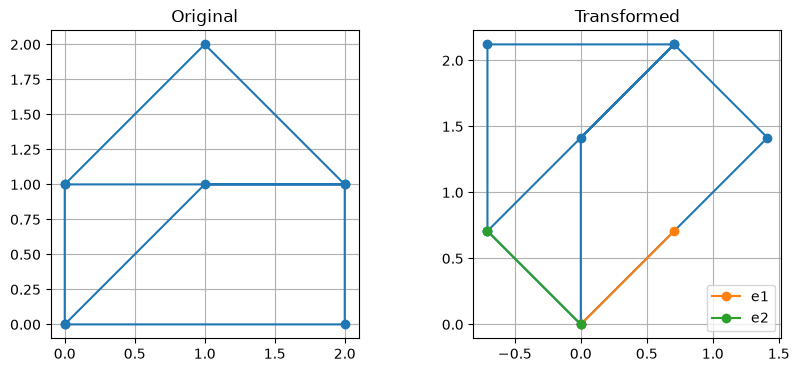

2. Pure scaling
2 0 0 2
3. Reflection
Matrix : 
[[ 1.  0.]
 [ 0. -1.]]
Basis e1 lands at :  [1. 0.]
Basis e2 lands at :  [ 0. -1.]
Determinant :  -1.0


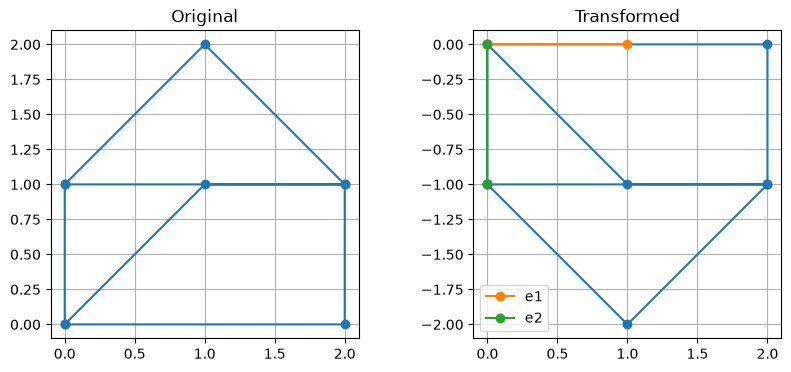

4. Negative determinant
Matrix : 
[[ 2.  0.]
 [ 0. -2.]]
Basis e1 lands at :  [2. 0.]
Basis e2 lands at :  [ 0. -2.]
Determinant :  -4.0


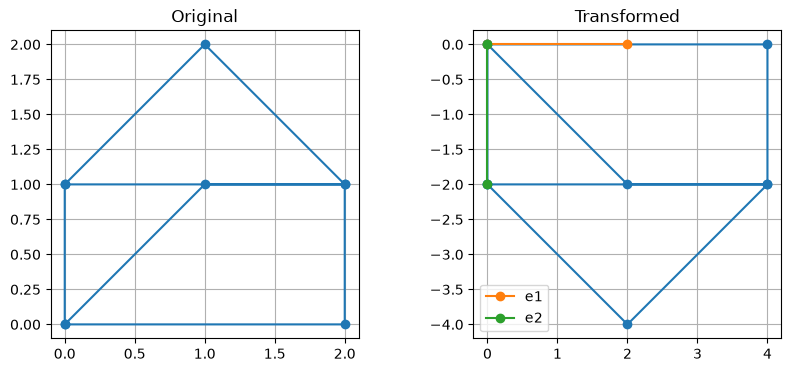

5. Collapse to a line
Matrix : 
[[1. 2.]
 [2. 4.]]
Basis e1 lands at :  [1. 2.]
Basis e2 lands at :  [2. 4.]
Determinant :  0.0


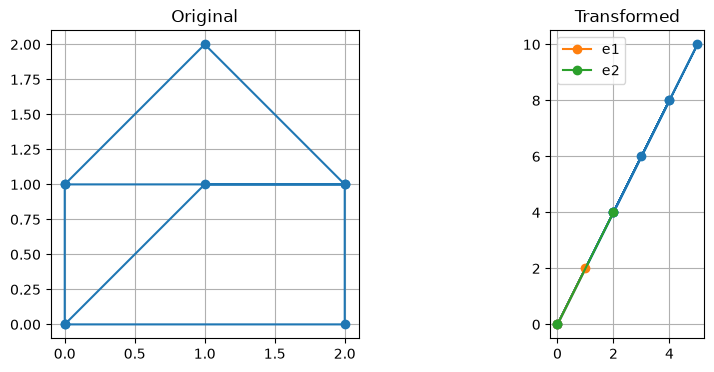


Reference Card
------------------------------------------------------------
MAtrix                 Effects                   Determinant
------------------------------------------------------------
Rotation 45°           Rotates shape             1
Scaling ×2             Enlarges shape            4
Reflection X           Flips vertically          -1
Scale + Reflection     Enlarges and flips        -4
Singular               Collapses to a line       0


In [40]:
def explore(a, b, c, d):
    # Create 2×2 transformation matrix
    M = np.array([
        [a, b],
        [c, d]
    ], dtype=float)
   
    # Apply transformation
    transformed = M @ shape

    # Print basis vector destinations
    print("Matrix : ")
    print(M)
    print("Basis e1 lands at : ", M[:, 0])
    print("Basis e2 lands at : ", M[:, 1])

    # print detrminant
    det = np.linalg.det(M)
    print("Determinant : ", det)
    
    # Before / after plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].plot(shape[0], shape[1], marker="o")
    axes[0].set_title("Original")
    axes[0].set_aspect("equal")
    axes[0].grid(True)
    
    axes[1].plot(transformed[0], transformed[1], marker="o")
    axes[1].plot([0, M[0, 0]],
                 [0, M[1, 0]], marker="o", label="e1")
    axes[1].plot([0, M[0, 1]],
                 [0, M[1, 1]], marker="o", label="e2")
    axes[1].set_title("Transformed")
    axes[1].set_aspect("equal")
    axes[1].grid(True)
    axes[1].legend()
    
    plt.show()
    
# ---------------------------------------------------------
# EXPERIMENTS
# ---------------------------------------------------------

# 1. Pure rotation — 45°
print("1. Pure rotation")
explore(np.cos(np.radians(45)), -np.sin(np.radians(45)),
        np.sin(np.radians(45)), np.cos(np.radians(45))
        )


# 2. Pure scaling — ×2
print("2. Pure scaling")
print(2, 0, 0, 2)


# 3. Reflection across x-axis
print("3. Reflection")
explore(1, 0, 0, -1)


# 4. Negative determinant but normal-looking scaling
# Scaling + reflection
print("4. Negative determinant")
explore(2, 0, 0, -2)
# Negative sign means the shape's orientation is flipped.


# 5. Collapse square/shape to a line
print("5. Collapse to a line")
explore(1, 2, 2, 4)
# det = 1×4 - 2×2 = 0

# ---------------------------------------------------------
# REFERENCE TABLE
# ---------------------------------------------------------

reference = [
    ["Rotation 45°", "Rotates shape", 1],
    ["Scaling ×2", "Enlarges shape", 4],
    ["Reflection X", "Flips vertically", -1],
    ["Scale + Reflection", "Enlarges and flips", -4],
    ["Singular", "Collapses to a line", 0]
]

print("\nReference Card")
print("-" * 60)
print(f"{'MAtrix' : <22} {'Effects' : <25} {'Determinant'}")
print("-" * 60)

for row in reference :
    print(f"{row[0] : <22} {row[1] : <25} {row[2]}")

### Look it up?

1. **Can you predict the determinant?**
   Yes. For \(\begin{bmatrix}a&b\\c&d\end{bmatrix}\), calculate **\(ad-bc\)**. If the two columns are proportional, the determinant is **0**. 

2. **What do the two columns tell you?**
   They show **where the two basis vectors land**. From them, you can predict stretching, rotation, shearing, and whether the shape may collapse.

3. **Which numbers always give determinant zero?**
   When **\(ad=bc\)** — meaning one column is a multiple of the other. This makes the transformation collapse a dimension. 

